# Лабораторна робота № 3. Лічильник на Hazelcast: розподілена мапа і IAtomicLong з CP Subsystem

Дисципліна «Проєктування високонавантажених систем», викладач Родіонов А. М.

Виконав: Вовкотруб Олександр Віталійович, група ФБ-61мн.
КПІ ім. Ігоря Сікорського, ННФТІ, кафедра інформаційної безпеки.

Ноутбук є аналітичною частиною звіту. Усі числа й обидва
рисунки звіту обчислюються тут із виміряних даних `reports/data/*.csv`,
уривки логів беруться з `reports/logs/hz-node*.log`. Наприкінці є жива
перевірка: справжні бінарники Swift на зменшеному навантаженні.

## 0. Підготовка середовища

Корінь репозиторію шукаємо від поточної теки вгору до `Package.swift`, тому
ноутбук однаково працює з `Labs/03-hazelcast/` і з кореня. Прапорець
`RUN_LIVE` вмикає розділ 6 зі справжніми запусками кластера й тестів;
вимкнути його можна змінною оточення `HLS_NB_LIVE=0`.

In [1]:
import os
import re
import shutil
import subprocess
import tempfile
import time
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display


def find_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "Package.swift").is_file():
            return path
    raise FileNotFoundError("Package.swift не знайдено вище від " + str(start))


ROOT = find_root(Path.cwd().resolve())
LAB = ROOT / "Labs" / "03-hazelcast"
DATA = ROOT / "reports" / "data"
LOGS = ROOT / "reports" / "logs"
ASSETS = LAB / "assets"
ASSETS.mkdir(exist_ok=True)

RUN_LIVE = os.environ.get("HLS_NB_LIVE", "1") != "0"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "DejaVu Sans"],
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 100,
})
pd.set_option("display.width", 160)

# Ті самі кольори, що й у презентації (slides/deck_theme.py), один колір на
# варіант або сховище в усіх рисунках.
INK, GRID = "#1A233B", "#D7DAE3"
VARIANT_COLOR = {
    "map-nolock": "#B5432F",
    "map-pessimistic": "#6B7280",
    "map-optimistic": "#0E6BA8",
    "atomic-long": "#1B8A5E",
}
STORE_COLOR = {
    "In-memory": "#6B7280",
    "Hazelcast (CP)": "#1B8A5E",
    "PostgreSQL": "#0E6BA8",
    "Disk (fsync)": "#B5432F",
}
VARIANTS = list(VARIANT_COLOR)


def uk(x: float, digits: int = 0) -> str:
    """Число в українському записі: 23 431,6 (нерозривний пробіл, кома)."""
    return f"{x:,.{digits}f}".replace(",", "\u00a0").replace(".", ",")


def save(fig, name: str) -> Path:
    """Зберегти рисунок у assets/ (dpi 200) і показати його в ноутбуці."""
    path = ASSETS / name
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path), width=820))
    print("збережено:", path.relative_to(ROOT))
    return path


def excerpt(rel: str, start: str, end: str | None = None, *, lines: int | None = None) -> None:
    """Надрукувати точний уривок файла з номерами рядків.

    Уривок починається з першого рядка, що містить `start`, і закінчується
    першим наступним рядком, що містить `end` (або через `lines` рядків).
    """
    text = (ROOT / rel).read_text(encoding="utf-8").splitlines()
    first = next(i for i, line in enumerate(text) if start in line)
    if end is not None:
        last = next(i for i in range(first + 1, len(text)) if end in text[i])
    else:
        last = first + (lines or 1) - 1
    print(f"{rel}, рядки {first + 1}...{last + 1}")
    for i in range(first, last + 1):
        print(f"{i + 1:4d} | {text[i]}")


print("корінь репозиторію:", ROOT.name)
print("RUN_LIVE =", RUN_LIVE)

корінь репозиторію: HighLoadSystems
RUN_LIVE = True


## 1. Постановка

Частина I. Кластер Hazelcast 5.4.0 із трьох вузлів на одній машині. Один
спільний лічильник збільшують 10 одночасних задач по 10 000 разів, тобто
очікується 100 000. Чотири способи інкременту:

| Варіант | Що робить кожна задача |
|---|---|
| `map-nolock` | `IMap.get`, +1 на клієнті, `IMap.put` |
| `map-pessimistic` | `lock`, `get`, `put`, `unlock` |
| `map-optimistic` | `get`, потім `replace(key, old, old + 1)` з повтором |
| `atomic-long` | `IAtomicLong.incrementAndGet()` у CP Subsystem |

Частина II. `IAtomicLong` як сховище веб-лічильника з роботи № 1
(`GET /inc`), 10 клієнтів по 10 000 запитів, порівняння зі сховищами в
пам'яті, на диску (файл з `fsync`) і в PostgreSQL.

Кожну конфігурацію виміряно тричі; у таблицях медіана, мінімум і максимум.

## 2. Власний клієнт Hazelcast для Swift

Офіційного клієнта для Swift немає, тому `Sources/HazelcastClient/`
реалізує Open Binary Client Protocol 2.x поверх SwiftNIO. Повідомлення
складається з кадрів: довжина `int32`, прапорці `uint16`, вміст. Кодувальник
пише кадри підряд і ставить прапорець `IS_FINAL` лише останньому:

In [2]:
excerpt("Sources/HazelcastClient/Protocol/ClientMessageCoding.swift",
        "public func encode(data message", lines=12)

Sources/HazelcastClient/Protocol/ClientMessageCoding.swift, рядки 9...20
   9 |     public func encode(data message: ClientMessage, out: inout ByteBuffer) throws {
  10 |         let lastIndex = message.frames.index(before: message.frames.endIndex)
  11 |         for (index, frame) in zip(message.frames.indices, message.frames) {
  12 |             var flags = frame.flags
  13 |             if index == lastIndex {
  14 |                 flags.insert(.isFinal)
  15 |             }
  16 |             out.writeInteger(Int32(frame.encodedLength), endianness: .little)
  17 |             out.writeInteger(flags.rawValue, endianness: .little)
  18 |             out.writeImmutableBuffer(frame.content)
  19 |         }
  20 |     }


Тести кодеків порівнюють байти кожного запиту з тим, що для тих самих
аргументів дає офіційний `hazelcast-python-client` 5.4.0. Нижче еталонний
запит `Map.Get` береться прямо з `Tests/HazelcastClientTests/CodecRequestTests.swift`
і розбирається на кадри тим самим правилом, що й у кодувальнику вище.

In [3]:
FLAG_NAMES = {15: "BEGIN_FRAGMENT", 14: "END_FRAGMENT", 13: "IS_FINAL",
              12: "BEGIN_DATA_STRUCTURE", 11: "END_DATA_STRUCTURE", 10: "IS_NULL"}

test_src = (ROOT / "Tests/HazelcastClientTests/CodecRequestTests.swift").read_text(encoding="utf-8")
block = test_src[test_src.index('@Test("Map.Get")'):test_src.index('@Test("Map.Put")')]
wire = bytes.fromhex("".join(re.findall(r'"([0-9a-f]+)"', block)))

frames, pos = [], 0
while pos < len(wire):
    length = int.from_bytes(wire[pos:pos + 4], "little")
    flags = int.from_bytes(wire[pos + 4:pos + 6], "little")
    content = wire[pos + 6:pos + length]
    frames.append({
        "кадр": len(frames) + 1,
        "довжина, байт": length,
        "прапорці": f"0x{flags:04x} " + "|".join(n for b, n in FLAG_NAMES.items() if flags >> b & 1),
        "вміст (hex)": content.hex(),
    })
    pos += length

frames_df = pd.DataFrame(frames).set_index("кадр")
head = wire[6:6 + 30 - 6]
print("тип повідомлення:", hex(int.from_bytes(head[0:4], "little")), "(Map.Get = 0x010200)")
print("correlation id:", int.from_bytes(head[4:12], "little", signed=True))
print("partition id:", int.from_bytes(head[12:16], "little", signed=True))
print("thread id:", int.from_bytes(head[16:24], "little", signed=True))
print("ім'я мапи:", frames[1]["вміст (hex)"], "=", bytes.fromhex(frames[1]["вміст (hex)"]).decode())
key = bytes.fromhex(frames[2]["вміст (hex)"])
print("ключ (Data): тип", int.from_bytes(key[4:8], "big", signed=True), "(-11 це рядок),",
      "довжина", int.from_bytes(key[8:12], "big"), "=", key[12:].decode())
assert sum(f["довжина, байт"] for f in frames) == len(wire)
frames_df

тип повідомлення: 0x10200 (Map.Get = 0x010200)
correlation id: 0
partition id: -1
thread id: 7
ім'я мапи: 636f756e74657273 = counters
ключ (Data): тип -11 (-11 це рядок), довжина 7 = counter


,"довжина, байт",прапорці,вміст (hex)
кадр,,,
1,30,0xc000 BEGIN_FRAGMENT|END_FRAGMENT,000201000000000000000000ffffffff0700000000000000
2,14,0x0000,636f756e74657273
3,25,0x2000 IS_FINAL,00000000fffffff500000007636f756e746572


Запит `Map.Get` займає 3 кадри і 69 байт: заголовок з типом, correlation id,
номером розділу й thread id, рядок з іменем мапи і серіалізований ключ у
форматі `Data`. Інкремент `IAtomicLong` це один такий запит
`AtomicLong.AddAndGet` до CP-групи:

In [4]:
excerpt("Sources/HazelcastClient/API/AtomicLong.swift", "public func addAndGet(", lines=5)

Sources/HazelcastClient/API/AtomicLong.swift, рядки 11...15
  11 |     public func addAndGet(_ delta: Int64) async throws -> Int64 {
  12 |         let request = AtomicLongAddAndGetCodec.encodeRequest(groupID: groupID, name: name, delta: delta)
  13 |         let response = try await client.invoke(request, expecting: AtomicLongAddAndGetCodec.responseType)
  14 |         return try AtomicLongAddAndGetCodec.decodeResponse(response)
  15 |     }


## 3. Частина I: чотири способи інкременту

`hz-bench` скидає лічильник у 0, запускає 10 задач у
`withThrowingTaskGroup` і міряє лише фазу інкрементів. Кожен спосіб
описано в `Sources/hz-bench/Variant.swift`:

In [5]:
excerpt("Sources/hz-bench/Variant.swift", "case (.mapNoLock, .map(", "preconditionFailure")

Sources/hz-bench/Variant.swift, рядки 62...89
  62 |         case (.mapNoLock, .map(let map, let key)):
  63 |             let value = try await map.get(key, threadID: threadID) ?? 0
  64 |             try await map.put(key, value + 1, threadID: threadID)
  65 |             return 0
  66 | 
  67 |         case (.mapPessimistic, .map(let map, let key)):
  68 |             try await map.withLock(key, threadID: threadID) {
  69 |                 let value = try await map.get(key, threadID: threadID) ?? 0
  70 |                 try await map.put(key, value + 1, threadID: threadID)
  71 |             }
  72 |             return 0
  73 | 
  74 |         case (.mapOptimistic, .map(let map, let key)):
  75 |             var retries = 0
  76 |             while true {
  77 |                 let value = try await map.get(key, threadID: threadID) ?? 0
  78 |                 if try await map.replace(key, expected: value, new: value + 1, threadID: threadID) {
  79 |                     return retri

Сирі дані: три повтори кожного варіанта, `reports/data/task3-bench.csv`.

In [6]:
bench = pd.read_csv(DATA / "task3-bench.csv")
assert set(bench["variant"]) == set(VARIANTS)
assert (bench["tasks"] * bench["increments_per_task"] == bench["expected"]).all()
bench

,repeat,variant,tasks,increments_per_task,seconds,increments_per_second,final_value,expected,lost_updates,retries
0,1,map-nolock,10,10000,5.9809,16719.8,20162,100000,79838,0
1,1,map-pessimistic,10,10000,60.5340,1652.0,100000,100000,0,0
2,1,map-optimistic,10,10000,27.4059,3648.8,100000,100000,0,455817
3,1,atomic-long,10,10000,4.2171,23713.2,100000,100000,0,0
4,2,map-nolock,10,10000,5.0819,19677.7,20263,100000,79737,0
5,2,map-pessimistic,10,10000,54.1938,1845.2,100000,100000,0,0
6,2,map-optimistic,10,10000,22.6567,4413.7,100000,100000,0,457866
7,2,atomic-long,10,10000,4.2677,23431.6,100000,100000,0,0
8,3,map-nolock,10,10000,5.1397,19456.5,20265,100000,79735,0
9,3,map-pessimistic,10,10000,59.0505,1693.5,100000,100000,0,0


Зведення: медіана, мінімум і максимум трьох повторів (таблиця 4.1 звіту),
фінальні значення й повтори кожного прогону (таблиця 4.2).

In [7]:
g = bench.groupby("variant", sort=False)
part1 = pd.DataFrame({
    "медіана, с": g["seconds"].median(),
    "мін., с": g["seconds"].min(),
    "макс., с": g["seconds"].max(),
    "інкр./с (медіана)": g["increments_per_second"].median(),
    "втрачено (медіана)": g["lost_updates"].median().astype(int),
    "повтори (медіана)": g["retries"].median().astype(int),
}).loc[VARIANTS]
part1["втрачено, %"] = 100 * part1["втрачено (медіана)"] / bench["expected"].iloc[0]
part1["повторів на інкремент"] = part1["повтори (медіана)"] / bench["expected"].iloc[0]
display(part1.round(2))

per_run = bench.pivot_table(index="variant", columns="repeat",
                            values=["final_value", "retries"], aggfunc="first").loc[VARIANTS]
display(per_run)

,"медіана, с","мін., с","макс., с",інкр./с (медіана),втрачено (медіана),повтори (медіана),"втрачено, %",повторів на інкремент
variant,,,,,,,,
map-nolock,5.14,5.08,5.98,19456.5,79737,0,79.74,0.00
map-pessimistic,59.05,54.19,60.53,1693.5,0,0,0.00,0.00
map-optimistic,27.41,22.66,41.30,3648.8,0,455817,0.00,4.56
atomic-long,4.27,4.22,4.34,23431.6,0,0,0.00,0.00


final_value                 retries                
repeat                    1       2       3       1       2       3
variant                                                            
map-nolock            20162   20263   20265       0       0       0
map-pessimistic      100000  100000  100000       0       0       0
map-optimistic       100000  100000  100000  455817  457866  453715
atomic-long          100000  100000  100000       0       0       0

In [8]:
t = part1["медіана, с"]
ratios = {
    "map-pessimistic / atomic-long": t["map-pessimistic"] / t["atomic-long"],
    "map-optimistic / atomic-long": t["map-optimistic"] / t["atomic-long"],
    "map-pessimistic / map-optimistic": t["map-pessimistic"] / t["map-optimistic"],
    "map-nolock / atomic-long": t["map-nolock"] / t["atomic-long"],
}
for name, value in ratios.items():
    print(f"{name}: {value:.2f}")
print(f"втрачено map-nolock: {part1.loc['map-nolock', 'втрачено, %']:.1f} %")
print(f"повторів на інкремент map-optimistic: {part1.loc['map-optimistic', 'повторів на інкремент']:.2f}")
print(f"мс на інкремент map-pessimistic: {1000 * t['map-pessimistic'] / 100_000:.2f}")

exact = bench[bench["variant"] != "map-nolock"]
assert (exact["final_value"] == exact["expected"]).all(), "коректні варіанти мають дати рівно 100 000"
assert (bench.loc[bench["variant"] == "map-nolock", "lost_updates"] > 0).all()

map-pessimistic / atomic-long: 13.84
map-optimistic / atomic-long: 6.42
map-pessimistic / map-optimistic: 2.15
map-nolock / atomic-long: 1.20
втрачено map-nolock: 79.7 %
повторів на інкремент map-optimistic: 4.56
мс на інкремент map-pessimistic: 0.59


Рисунок 4.1 звіту: смуга це медіана, риска з засічками це мінімум і
максимум, точки це окремі повтори.

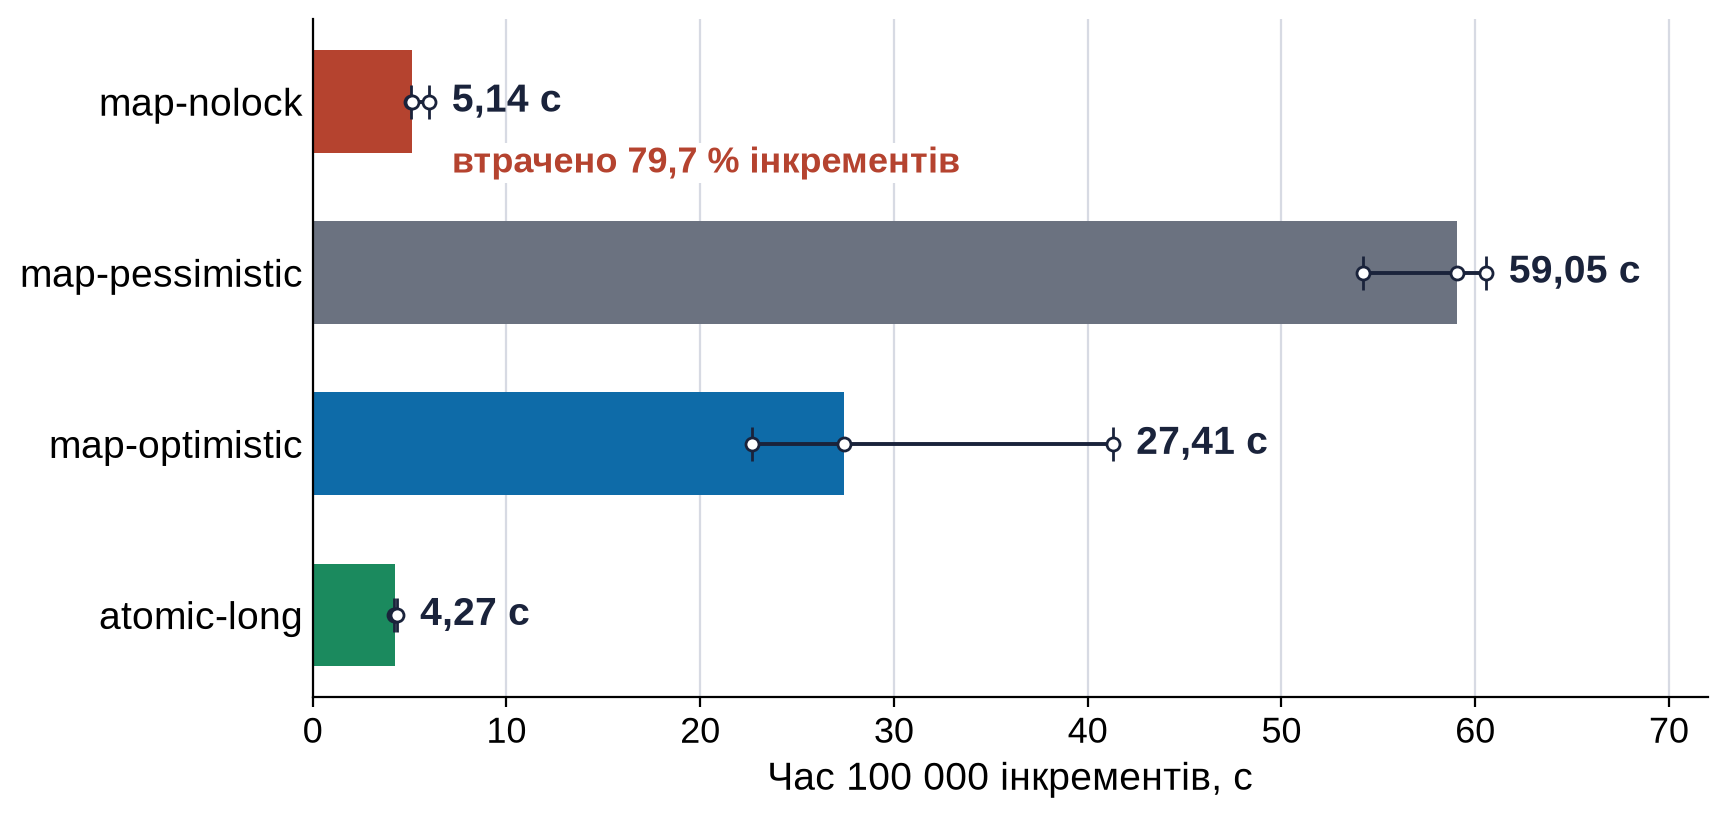

збережено: Labs/03-hazelcast/assets/01-part1-variants-time.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 4.4))
order = VARIANTS[::-1]  # перший варіант зверху
y = range(len(order))
for i, v in zip(y, order):
    row = part1.loc[v]
    color = VARIANT_COLOR[v]
    ax.barh(i, row["медіана, с"], height=0.6, color=color, zorder=2)
    ax.errorbar(row["медіана, с"], i,
                xerr=[[row["медіана, с"] - row["мін., с"]], [row["макс., с"] - row["медіана, с"]]],
                fmt="none", ecolor=INK, elinewidth=1.4, capsize=6, zorder=3)
    runs = bench.loc[bench["variant"] == v, "seconds"]
    ax.scatter(runs, [i] * len(runs), s=22, color="white", edgecolor=INK, linewidth=1, zorder=4)
    label = f"{uk(row['медіана, с'], 2)} с"
    ax.text(row["макс., с"] + 1.2, i, label, va="center", ha="left", color=INK, fontsize=14,
            fontweight="bold")
    if v == "map-nolock":
        ax.text(row["макс., с"] + 1.2, i - 0.36,
                f"втрачено {uk(row['втрачено, %'], 1)} % інкрементів",
                va="center", ha="left", color=color, fontsize=13, fontweight="bold",
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 1}, zorder=5)
ax.set_yticks(list(y), order)
ax.set_xlim(0, 72)
ax.set_xlabel("Час 100 000 інкрементів, с")
ax.xaxis.grid(True, color=GRID, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
save(fig, "01-part1-variants-time.png");

`map-nolock` швидкий (медіана 5,14 с), але втрачає 79,7 % інкрементів:
кожна з операцій `get` і `put` атомарна, а пара разом ні, тому одночасні
задачі записують те саме `v + 1`. `map-pessimistic` коректний, але
найповільніший (59,05 с, у 13,8 раза довше за `atomic-long`), бо
критичні секції 10 задач ідуть строго по черзі і кожна коштує чотири
запити. `map-optimistic` вдвічі швидший за `lock` (27,41 с), але має
найбільший розкид (22,66...41,30 с) і 4,56 повтору на інкремент.
`atomic-long` коректний і найшвидший (4,27 с): один запит на інкремент,
читання і запис відбуваються всередині CP-групи.

## 4. Логи кластера: CP Subsystem і Raft

Логи трьох вузлів з того самого запуску, на якому знято `task3-bench.csv`.
Функція `grep` нижче знаходить потрібні рядки, а `strip` прибирає префікс
log4j (дата, рівень, потік, адреса вузла), як у звіті.

In [10]:
PREFIX = re.compile(r"^\d{4}-\d\d-\d\d (\d\d:\d\d:\d\d,\d+) \[ ?\w+\] \[[^\]]*\] \[([^\]]*)\]: \[[^\]]*\]:\d+ \[dev\] \[5\.4\.0\] ")


def strip(line: str) -> str:
    return PREFIX.sub(lambda m: f"{m[1]} [{m[2].split('.')[-1]}] ", line.rstrip())


def grep(node: int, pattern: str, after: int = 0, limit: int | None = None,
         having: str | None = None) -> list[tuple[int, str]]:
    """Рядки лога вузла, що збігаються з pattern, і `after` рядків після кожного.

    Якщо задано `having`, береться лише той блок, у якому є цей підрядок.
    """
    lines = (LOGS / f"hz-node{node}.log").read_text(encoding="utf-8").splitlines()
    out = []
    for i, line in enumerate(lines):
        if re.search(pattern, line):
            if having and not any(having in l for l in lines[i:i + 1 + after]):
                continue
            out.extend((j + 1, strip(lines[j])) for j in range(i, min(i + 1 + after, len(lines))))
            if limit and len(out) >= limit:
                break
    return out


def show(node: int, pattern: str, after: int = 0, limit: int | None = None,
         having: str | None = None) -> None:
    print(f"--- hz-node{node}.log, /{pattern}/")
    for n, line in grep(node, pattern, after, limit, having):
        print(f"{n:4d} | {line[:118]}")


show(2, r"Hazelcast Platform 5\.4\.0 .* starting")
show(2, r"CP Subsystem is enabled with")
show(2, r"^Members \{size:3", after=4)
show(1, r"We are the LEADER!", limit=1)
show(1, r"CP Group Members \{groupId: METADATA\(0\), size:3, term:1", after=4, limit=5,
     having="LEADER this")

--- hz-node2.log, /Hazelcast Platform 5\.4\.0 .* starting/
  16 | 18:52:33,008 [system] Hazelcast Platform 5.4.0 (20240415) starting at [127.0.0.1]:5702
--- hz-node2.log, /CP Subsystem is enabled with/
  31 | 18:52:34,342 [CPSubsystem] CP Subsystem is enabled with 3 members.
--- hz-node2.log, /^Members \{size:3/
  40 | Members {size:3, ver:3} [
  41 | 	Member [127.0.0.1]:5701 - 89211daa-dca9-4cd9-ab96-01a4ee1c39ae
  42 | 	Member [127.0.0.1]:5703 - 255cb7ad-4963-4017-a75b-6fcce9b43890
  43 | 	Member [127.0.0.1]:5702 - 1d98c7c6-827f-485a-945b-f73dcf06362a this
  44 | ]
--- hz-node1.log, /We are the LEADER!/
  87 | 18:52:42,792 [VoteResponseHandlerTask(METADATA)] We are the LEADER!
--- hz-node1.log, /CP Group Members \{groupId: METADATA\(0\), size:3, term:1/
  90 | CP Group Members {groupId: METADATA(0), size:3, term:1, logIndex:0} [
  91 | 	CPMember{uuid=89211daa-dca9-4cd9-ab96-01a4ee1c39ae, address=[127.0.0.1]:5701} - LEADER this
  92 | 	CPMember{uuid=1d98c7c6-827f-485a-945b-f73dcf06362

Група `default`, у якій живе `IAtomicLong`, створюється при першому
зверненні до лічильника. Після першого прогону `atomic-long` лідер вузол 1
передає лідерство, і вузол 3 виграє вибори в термі 2:

In [11]:
show(1, r"New CPGroupId\{name='default'")
show(3, r"TriggerLeaderElectionHandlerTask\(default\)|LeaderElectionTask\(default\)|"
     r"VoteResponseHandlerTask\(default\).*(Vote granted|LEADER!)")
show(3, r"CP Group Members \{groupId: default\(\d+\), size:3, term:2", after=4, limit=5,
     having="LEADER this")

--- hz-node1.log, /New CPGroupId\{name='default'/
 128 | 18:54:32,514 [MetadataRaftGroupManager] New CPGroupId{name='default', seed=0, groupId=3883} is created with [CPMember{
--- hz-node3.log, /TriggerLeaderElectionHandlerTask\(default\)|LeaderElectionTask\(default\)|VoteResponseHandlerTask\(default\).*(Vote granted|LEADER!)/
 106 | 18:54:43,609 [TriggerLeaderElectionHandlerTask(default)] Starting a new leader election since the current leader: Raft
 107 | 18:54:43,612 [LeaderElectionTask(default)] Leader election started for term: 2, last log index: 100002, last log term:
 116 | 18:54:43,616 [VoteResponseHandlerTask(default)] Vote granted from RaftEndpoint{uuid='1d98c7c6-827f-485a-945b-f73dcf063
 117 | 18:54:43,617 [VoteResponseHandlerTask(default)] We are the LEADER!
--- hz-node3.log, /CP Group Members \{groupId: default\(\d+\), size:3, term:2/
 120 | CP Group Members {groupId: default(3883), size:3, term:2, logIndex:0} [
 121 | 	CPMember{uuid=1d98c7c6-827f-485a-945b-f73dcf06362a, a

In [12]:
events = []
for node in (1, 2, 3):
    for n, line in grep(node, r"CP Group Members \{groupId: (\w+)\(\d+\), size:(\d+), term:(\d+)"):
        m = re.search(r"groupId: (\w+)\(\d+\), size:(\d+), term:(\d+)", line)
        if m:
            events.append({"вузол": node, "група": m[1], "size": int(m[2]), "term": int(m[3])})
cp_groups = (pd.DataFrame(events).groupby(["група", "вузол"])
             .agg(записів=("size", "size"), size=("size", "max"), макс_term=("term", "max")))
display(cp_groups)

last_index = int(re.search(r"last log index: (\d+)",
                           grep(3, r"Leader election started for term: 2")[0][1])[1])
print("last log index при виборах у термі 2:", last_index)
assert (cp_groups["size"] == 3).all()
assert last_index >= 100_000

записів  size  макс_term
група    вузол                          
METADATA 1            3     3          1
         2            2     3          1
         3            2     3          1
default  1            5     3          2
         2            4     3          2
         3            4     3          2

last log index при виборах у термі 2: 100002


Обидві CP-групи (METADATA і `default`) на всіх трьох вузлах мають
`size:3`. Вибори в термі 2 почалися при `last log index: 100002`: кожен із
100 000 інкрементів першого прогону `atomic-long` ліг у Raft-лог групи
окремим записом, плюс службові записи (зокрема `set(0)`).

## 5. Частина II: веб-лічильник на IAtomicLong

Сховище `HazelcastCounterStore` реалізує той самий протокол `CounterStore`,
що й сховища робіт № 1 і № 2, тож `counter-server` лишився незмінним:

In [13]:
excerpt("Sources/CounterCore/HazelcastCounterStore.swift", "public func increment() async", lines=3)

Sources/CounterCore/HazelcastCounterStore.swift, рядки 109...111
 109 |     public func increment() async throws {
 110 |         try await counter.incrementAndGet()
 111 |     }


Дані для порівняння: пам'ять і диск з `task1.csv` (лише рядки з 10
клієнтами), PostgreSQL з `task2-web.csv`, Hazelcast з `task3-web.csv`.
Скрізь 10 клієнтів по 10 000 запитів.

In [14]:
t1 = pd.read_csv(DATA / "task1.csv")
web = pd.concat([
    t1[t1["clients"] == 10],
    pd.read_csv(DATA / "task2-web.csv"),
    pd.read_csv(DATA / "task3-web.csv"),
], ignore_index=True)
web["сховище"] = web["store"].map({"memory": "In-memory", "disk": "Disk (fsync)",
                                   "postgres": "PostgreSQL", "hazelcast": "Hazelcast (CP)"})
assert (web["total_requests"] == 100_000).all() and web["correct"].all()
display(web[["сховище", "repeat", "seconds", "rps", "final_value", "correct"]])

STORES = ["In-memory", "Disk (fsync)", "PostgreSQL", "Hazelcast (CP)"]
w = web.groupby("сховище")
part2 = pd.DataFrame({
    "медіана, с": w["seconds"].median(),
    "мін., с": w["seconds"].min(),
    "макс., с": w["seconds"].max(),
    "запитів/с (медіана)": w["rps"].median(),
    "мін. запитів/с": w["rps"].min(),
    "макс. запитів/с": w["rps"].max(),
}).loc[STORES]
display(part2.round(2))

,сховище,repeat,seconds,rps,final_value,correct
0,In-memory,1,2.9155,34299.7,100000,True
1,In-memory,2,3.3096,30215.1,100000,True
2,In-memory,3,3.1994,31256.0,100000,True
3,Disk (fsync),1,818.0793,122.2,100000,True
4,Disk (fsync),2,814.2633,122.8,100000,True
5,Disk (fsync),3,824.1182,121.3,100000,True
6,PostgreSQL,1,199.7578,500.6,100000,True
7,PostgreSQL,2,302.4360,330.6,100000,True
8,PostgreSQL,3,306.1745,326.6,100000,True
9,Hazelcast (CP),1,8.7884,11378.6,100000,True


,"медіана, с","мін., с","макс., с",запитів/с (медіана),мін. запитів/с,макс. запитів/с
сховище,,,,,,
In-memory,3.20,2.92,3.31,31256.0,30215.1,34299.7
Disk (fsync),818.08,814.26,824.12,122.2,121.3,122.8
PostgreSQL,302.44,199.76,306.17,330.6,326.6,500.6
Hazelcast (CP),8.88,8.79,9.08,11259.7,11007.6,11378.6


In [15]:
r = part2["запитів/с (медіана)"]
hz = r["Hazelcast (CP)"]
print(f"In-memory / Hazelcast: {r['In-memory'] / hz:.2f}")
print(f"Hazelcast / PostgreSQL: {hz / r['PostgreSQL']:.2f}")
print(f"Hazelcast / Disk: {hz / r['Disk (fsync)']:.2f}")
hz_bench = part1.loc["atomic-long", "інкр./с (медіана)"]
print(f"hz-bench atomic-long / веб-лічильник: {hz_bench / hz:.2f}")
spread = part2.loc["Hazelcast (CP)"]
print(f"розкид часу Hazelcast: {100 * (spread['макс., с'] - spread['мін., с']) / spread['медіана, с']:.1f} %")

In-memory / Hazelcast: 2.78
Hazelcast / PostgreSQL: 34.06
Hazelcast / Disk: 92.14
hz-bench atomic-long / веб-лічильник: 2.08
розкид часу Hazelcast: 3.3 %


Рисунок 4.2 звіту: логарифмічна шкала, бо сховища відрізняються на два
з половиною порядки. Смуга це медіана, риска це мінімум і максимум.

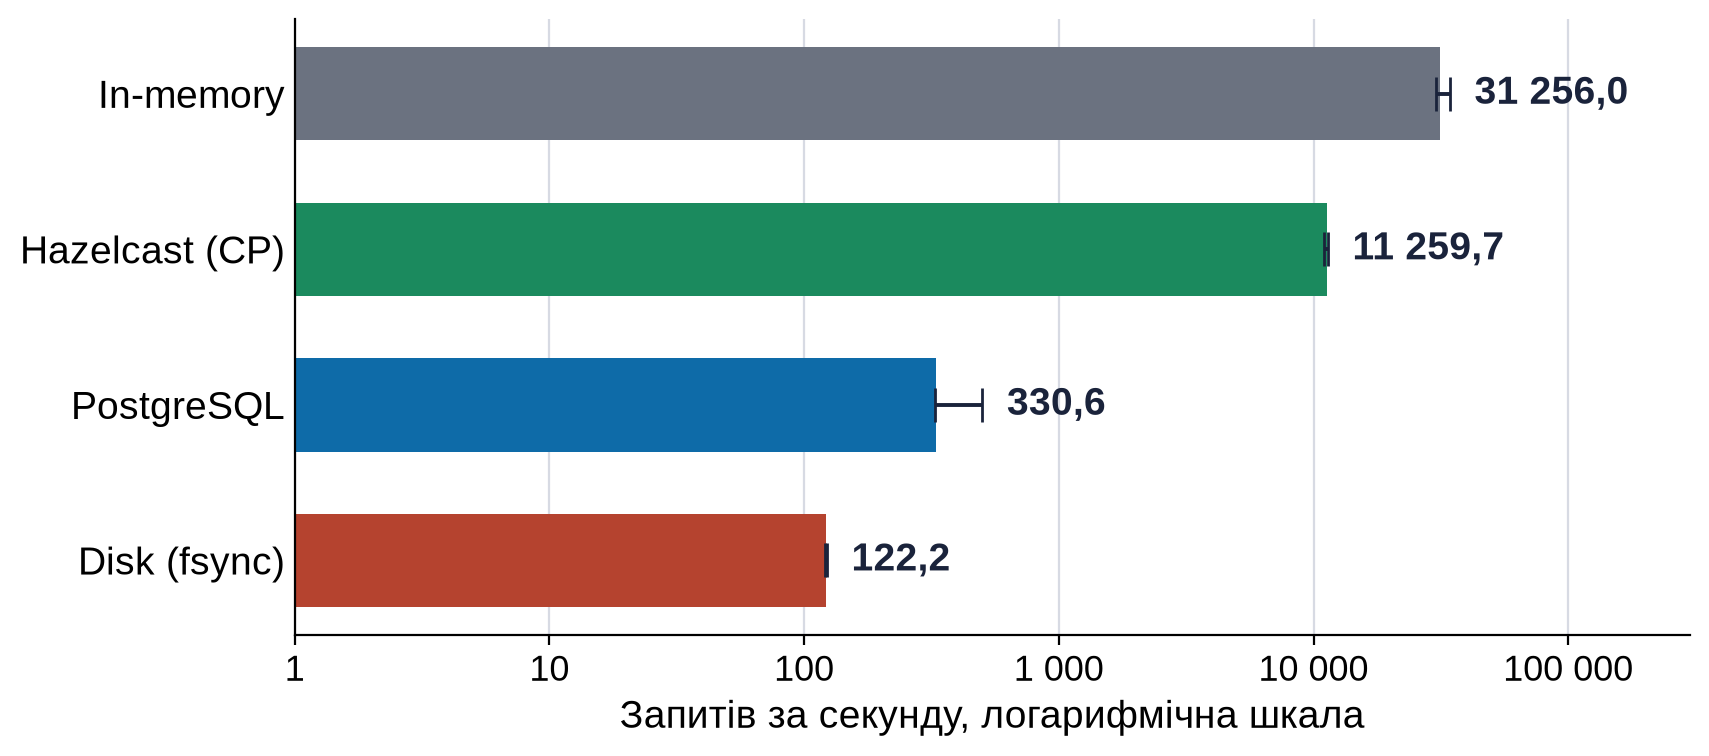

збережено: Labs/03-hazelcast/assets/02-part2-stores-rps.png


In [16]:
fig, ax = plt.subplots(figsize=(9, 4.0))
order = part2.sort_values("запитів/с (медіана)").index.tolist()  # найшвидше зверху
for i, s in enumerate(order):
    row = part2.loc[s]
    med = row["запитів/с (медіана)"]
    ax.barh(i, med, height=0.6, color=STORE_COLOR[s], zorder=2)
    ax.errorbar(med, i, xerr=[[med - row["мін. запитів/с"]], [row["макс. запитів/с"] - med]],
                fmt="none", ecolor=INK, elinewidth=1.4, capsize=6, zorder=3)
    ax.text(row["макс. запитів/с"] * 1.25, i, uk(med, 1), va="center", ha="left",
            color=INK, fontsize=14, fontweight="bold")
ax.set_yticks(range(len(order)), order)
ax.set_xscale("log")
ax.set_xlim(1, 3e5)
ax.set_xticks([1, 10, 100, 1_000, 10_000, 100_000],
              ["1", "10", "100", uk(1_000), uk(10_000), uk(100_000)])
ax.minorticks_off()
ax.set_xlabel("Запитів за секунду, логарифмічна шкала")
ax.xaxis.grid(True, color=GRID, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
save(fig, "02-part2-stores-rps.png");

Hazelcast у 2,8 раза повільніший за пам'ять процесу (11 259,7 проти
31 256,0 запитів/с), бо кожен HTTP-запит додає запит до вузла, пересилання
лідеру CP-групи і Raft-реплікацію. Водночас він у 34 рази швидший за
PostgreSQL і в 92 рази швидший за файл з `fsync`: обидва ці сховища чекають
на диск при кожному інкременті, а Hazelcast реплікує значення в пам'ять
інших вузлів. Прямий `hz-bench atomic-long` дає вдвічі більше (23 431,6
інкр./с), різниця припадає на HTTP. Розкид Hazelcast між повторами
близько 3 %.

## 6. Жива перевірка

Цей розділ запускає справжні бінарники зі `Sources/` на **зменшеному
навантаженні**. Це демонстрація того, що код працює, а не вимірювання:
офіційні числа звіту взято з CSV у розділах 3 і 5. Кожна клітинка
вкладається приблизно в хвилину і в `finally` прибирає все, що запустила.

Команди виконуються через `scripts/env.sh`, тобто з тими самими шляхами
й портами, що й скрипти вимірювань.

In [17]:
def sh(cmd: str, timeout: int, env: dict | None = None, check: bool = True) -> subprocess.CompletedProcess:
    """Виконати команду bash у корені репозиторію з оточенням scripts/env.sh."""
    full_env = {**os.environ, **(env or {})}
    proc = subprocess.run(["bash", "-lc", f"cd '{ROOT}' && source scripts/env.sh && {cmd}"],
                          capture_output=True, text=True, timeout=timeout, env=full_env)
    if check and proc.returncode != 0:
        raise RuntimeError(f"`{cmd}` завершилася з кодом {proc.returncode}:\n"
                           + proc.stdout[-2000:] + proc.stderr[-2000:])
    return proc

### 6.1. Тести кодування кадрів

Запускаємо два набори тестів клієнта: `FrameCodingTests` (кодування й
розбір кадрів, прапорець `IS_FINAL`, байт за байтом через канал NIO) і
`CodecRequestTests` (байти запитів проти еталону офіційного клієнта, як у
розділі 2). Живий кластер для них не потрібен.

In [18]:
if RUN_LIVE:
    t0 = time.monotonic()
    proc = sh("swift test --filter 'FrameCodingTests|CodecRequestTests' 2>&1", timeout=600, check=False)
    elapsed = time.monotonic() - t0
    out = proc.stdout
    passed = re.findall(r'✔ Test "([^"]+)" passed', out)
    summary = [line.strip() for line in out.splitlines() if re.search(r"Test run with \d+ tests?", line)]
    print("пройшли:", ", ".join(passed))
    print("\n".join(summary) or out[-1500:])
    print(f"код виходу {proc.returncode}, {elapsed:.1f} с разом зі збіркою тестів")
    assert proc.returncode == 0 and summary and "passed" in summary[-1]
else:
    print("RUN_LIVE = False: тести не запускались")

пройшли: the correlation and partition ids land in the request header, Map.Unlock, only the last frame carries IS_FINAL on the wire, Client.Ping, CPGroup.CreateCPGroup, Map.Lock, AtomicLong.AddAndGet, AtomicLong.GetAndSet, Client.Authentication, Map.Get, Map.ReplaceIfSame, a frame over the size limit is rejected, a frame shorter than its header is rejected, Map.Put, a message survives encode and parse unchanged, the parser waits for a frame delivered one byte at a time, AtomicLong.Get, the protocol header handler sends CP2 when the channel becomes active, the NIO handlers encode and decode through a channel
✔ Test run with 19 tests in 2 suites passed after 0.002 seconds.
код виходу 0, 13.4 с разом зі збіркою тестів


### 6.2. Кластер і hz-bench: втрачені оновлення проти точного лічильника

Клітинка піднімає кластер з трьох вузлів (`scripts/hz.sh start` чекає,
доки CP Subsystem сформується), проганяє `hz-bench` для `map-nolock` і
`atomic-long` з 10 задачами по 300 інкрементів (3 000 замість 100 000) і
зупиняє кластер у `finally`. Логи вузлів ідуть у тимчасову теку
(`HLS_LOG_DIR`), тож `reports/logs` не перезаписується. Якщо кластер уже
працював, клітинка його використовує і не зупиняє.

In [19]:
live = None
if RUN_LIVE:
    log_dir = Path(tempfile.mkdtemp(prefix="hls-nb03-"))
    env = {"HLS_LOG_DIR": str(log_dir)}
    started = False
    rows, live_logs = [], {}
    t0 = time.monotonic()
    try:
        sh("test -x .build/release/hz-bench || hls_build_release --product hz-bench", timeout=900, env=env)
        # status завершується з кодом 1, коли не працює жоден вузол
        running = "running" in sh("scripts/hz.sh status", timeout=30, env=env, check=False).stdout
        if not running:
            started = True
            sh("HZ_START_TIMEOUT=90 scripts/hz.sh start", timeout=120, env=env)
        print(f"кластер готовий за {time.monotonic() - t0:.1f} с")
        for variant in ("map-nolock", "atomic-long"):
            res = sh(f'"$HLS_BIN/hz-bench" --header --variant {variant} --tasks 10 --increments 300 '
                     '--address "$HZ_ADDRESS"', timeout=60, env=env)
            rows.append(pd.read_csv(pd.io.common.StringIO(res.stdout)))
        for node in (1, 2, 3):
            path = log_dir / f"hz-node{node}.log"
            if path.exists():
                live_logs[node] = path.read_text(encoding="utf-8", errors="replace").splitlines()
    finally:
        if started:
            sh("scripts/hz.sh stop", timeout=120, env=env, check=False)
        shutil.rmtree(log_dir, ignore_errors=True)
    print(f"разом {time.monotonic() - t0:.1f} с, кластер {'зупинено' if started else 'лишився працювати'}")

    live = pd.concat(rows, ignore_index=True)
    display(live)
    for node, lines in live_logs.items():
        hit = next((l for l in lines if re.search(r"CP Group Members \{groupId: METADATA\(0\), size:3", l)), None)
        print(f"hz-node{node}: {hit.strip() if hit else 'рядок CP Group Members не знайдено'}")
else:
    print("RUN_LIVE = False: кластер не запускався")

кластер готовий за 11.4 с


разом 18.1 с, кластер зупинено


,variant,tasks,increments_per_task,seconds,increments_per_second,final_value,expected,lost_updates,retries
0,map-nolock,10,300,0.4035,7435.6,629,3000,2371,0
1,atomic-long,10,300,0.3542,8470.5,3000,3000,0,0


hz-node1: CP Group Members {groupId: METADATA(0), size:3, term:1, logIndex:0} [
hz-node2: CP Group Members {groupId: METADATA(0), size:3, term:0, logIndex:0} [
hz-node3: CP Group Members {groupId: METADATA(0), size:3, term:1, logIndex:0} [


In [20]:
if live is not None:
    ints = live.set_index("variant")[["final_value", "expected", "lost_updates"]].astype(int)
    nolock, atomic = ints.loc["map-nolock"], ints.loc["atomic-long"]
    print(f"map-nolock: {nolock.final_value} з {nolock.expected}, "
          f"втрачено {nolock.lost_updates} ({100 * nolock.lost_updates / nolock.expected:.1f} %)")
    print(f"atomic-long: {atomic.final_value} з {atomic.expected}, втрачено {atomic.lost_updates}")
    assert atomic.final_value == atomic.expected
    assert nolock.final_value < nolock.expected

map-nolock: 629 з 3000, втрачено 2371 (79.0 %)
atomic-long: 3000 з 3000, втрачено 0


Навіть на 3 000 інкрементах `map-nolock` втрачає частину оновлень, а
`atomic-long` дає рівно 3 000. Час і пропускна здатність тут не показові:
прогін короткий, JVM вузлів щойно стартували і ще не прогріті.

## 7. Висновки

1. Кластер Hazelcast 5.4.0 з трьох вузлів сформував CP Subsystem: у логах
   усіх вузлів групи METADATA і `default` мають `size:3`, лідер обирається
   за Raft. Для роботи з кластером написано власний клієнт на Swift, його
   кадри збігаються байт у байт з офіційним клієнтом.
2. `IMap.get` і `IMap.put` без синхронізації втратили 79,7 % інкрементів
   (медіана 79 737 з 100 000). Атомарною має бути вся пара «прочитати,
   записати», а не кожна операція окремо.
3. `IMap` з `lock` коректний, але найповільніший: 59,05 с, у 13,8 раза
   довше за `IAtomicLong`. `replace` коректний і вдвічі швидший (27,41 с),
   але робить 4,56 повтору на кожен успішний інкремент.
4. `IAtomicLong` у CP Subsystem коректний і найшвидший: 4,27 с, 23 431,6
   інкр./с, один запит на інкремент. Кожен інкремент є окремим записом
   Raft-логу (`last log index: 100002`).
5. Як сховище веб-лічильника Hazelcast дав 11 259,7 запитів/с: у 2,8 раза
   повільніше за пам'ять, але в 34 рази швидше за PostgreSQL і в 92 рази
   швидше за файл з `fsync`.